# SASE FEL Pulse Generation and Visualization Notebook

This notebook simulates a multi-spike Self-Amplified Spontaneous Emission (SASE) Free-Electron Laser (FEL) pulse based on statistical models. A SASE pulse is modeled as a superposition of independent, finite Gaussian pulses (spikes) with random phases.

The notebook generates the complex electric field in the time domain, applies a Fourier Transform to move into the frequency domain, shifts the energy axis to electron-volts ($\text{eV}$) relative to the central photon energy, and plots the amplitude and phase for both domains.

## Free Parameters Configuration

Below are the free parameters used in this simulation. You can modify these values in the next code cell to change the pulse characteristics. **Current values** match the configuration cell below (see also the mathematical documentation cell for derived quantities):

* `N_POINTS` (Fixed to **64**): The number of discrete sampling points in the time domain.
* `T_TOTAL` (Fixed to **100 fs**): The total time window of the simulation in femtoseconds ($1\text{ fs} = 10^{-15}\text{ s}$).
* `N_SPIKES` (**30**): Number of statistically independent Gaussian spikes within the single pulse.
* `CENTRAL_ENERGY_EV` (**10,000.0 eV**): The central photon energy around which the pulse spectrum is centered.
* `COHERENCE_TIME_AS` (**2.5 fs**): The typical duration ($\sigma_{\mathrm{spike}}$) of a single independent spike.
* `DELTA_ENERGY_EV_RANGE` (**0.00065 eV**): Half-range of spike frequency deviation mapped to energy.
* `FIELD_TO_PLOT` (**`"all"`**): Which electric-field model to visualize — `"modified_c1"`, `"quadratic_chirp"`, `"smoothed_phase_noise"`, `"both"` (first two), or `"all"` (all three side by side).
* `BETA_FACTOR` (**−0.6**): Dimensionless scale for the quadratic chirp coefficient $\beta = \text{BETA\_FACTOR} \times \Delta\omega_{\max} / (4\,\sigma_{\text{spike}})$ in the quadratic-chirp model.
* `PHASE_NOISE_STD` (**$0.2\pi \approx 0.628$ rad**): Standard deviation of raw white-noise phase samples per spike about a random offset $\theta_k$, before smoothing.
* `PHASE_SMOOTH_SIGMA` (**1.6**): Gaussian smoother width (samples) applied to each spike's phase noise vector.

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# EXPLICIT FREE PARAMETERS CONFIGURATION
# ==========================================
N_POINTS = 64              # Strict Requirement: Number of time sampling points
T_TOTAL = 100.0            # Strict Requirement: Total time window in femtoseconds (fs)
N_SPIKES = 30               # Free Parameter: Number of independent SASE spikes (typical range: 2-5)
CENTRAL_ENERGY_EV = 10000.0  # Free Parameter: Central photon energy in eV (from article lambda = 2.5 nm)
COHERENCE_TIME_AS = 2.5    # Free Parameter: Duration (sigma_spike) of an individual spike in femtoseconds. Note: This corresponds to sigma_spike in Formula C1.
DELTA_ENERGY_EV_RANGE = 6.5 * 0.0001 # Free Parameter: Range for Delta_omega_i in eV, derived from Formula C1 (e.g., 58.5 eV)

# Calculate DELTA_OMEGA_RELATIVE_RANGE from DELTA_ENERGY_EV_RANGE
# Delta E = h_bar * Delta omega => Delta omega = Delta E / h_bar
# h_bar = PLANCK_CONSTANT_AS_EV / (2 * np.pi)
# omega_0 = CENTRAL_ENERGY_EV * (2 * np.pi) / PLANCK_CONSTANT_AS_EV
# DELTA_OMEGA_RELATIVE_RANGE = (Delta omega_range / 2) / omega_0
# Since the 'Delta omega_i' uniform range is +/- DELTA_OMEGA_RELATIVE_RANGE * omega_0,
# and the corresponding energy range for Delta E is +/- DELTA_ENERGY_EV_RANGE / 2,
# we can derive that DELTA_OMEGA_RELATIVE_RANGE = DELTA_ENERGY_EV_RANGE / CENTRAL_ENERGY_EV
DELTA_OMEGA_RELATIVE_RANGE = DELTA_ENERGY_EV_RANGE / CENTRAL_ENERGY_EV

# Electric-field model selection:
#   "modified_c1"           -> constant random phase per spike
#   "quadratic_chirp"       -> beta*(t-t_k)^2 + theta_k per spike
#   "smoothed_phase_noise"  -> time-dependent smoothed white-noise phase per spike
#   "both"                  -> modified C1 + quadratic chirp
#   "all"                   -> all three models side by side
FIELD_TO_PLOT = "all"

# Quadratic chirp strength: beta = BETA_FACTOR * Delta_omega_max / (4 * sigma_spike)
BETA_FACTOR = -0.6

# Smoothed phase noise (per spike k): N(theta_k, PHASE_NOISE_STD^2) on t-grid, theta_k random, then Gaussian smooth
PHASE_NOISE_STD = 0.2 * np.pi
PHASE_SMOOTH_SIGMA = 1.6

print(f"Configuration loaded successfully.")
print(f"Simulating {N_SPIKES} spikes over a {T_TOTAL} fs window with {N_POINTS} points.")
print(f"Using Delta_omega_i with energy range {DELTA_ENERGY_EV_RANGE} eV.")
print(f"Derived DELTA_OMEGA_RELATIVE_RANGE: {DELTA_OMEGA_RELATIVE_RANGE}")
print(f"Field model for plotting: {FIELD_TO_PLOT}")
print(f"Quadratic chirp BETA_FACTOR: {BETA_FACTOR}")
print(f"Smoothed phase noise: std={PHASE_NOISE_STD:.3f} rad, smooth sigma={PHASE_SMOOTH_SIGMA}")

Configuration loaded successfully.
Simulating 30 spikes over a 100.0 fs window with 64 points.
Using Delta_omega_i with energy range 0.0006500000000000001 eV.
Derived DELTA_OMEGA_RELATIVE_RANGE: 6.500000000000001e-08
Field model for plotting: all
Quadratic chirp BETA_FACTOR: -0.6
Smoothed phase noise: std=0.628 rad, smooth sigma=1.6


## Mathematical Documentation: Electric Fields, Amplitude & Phase

This section summarizes the **complex electric fields** computed and plotted in this notebook, how **amplitude** and **phase** are extracted from them, and the **current parameter values** loaded in the configuration cell above.

---

### 1. Common setup

**Time grid** (64 samples over 100 fs):

$$t_j = -\frac{T_{\mathrm{total}}}{2} + j\,\Delta t, \qquad j = 0,\ldots,N_{\mathrm{points}}-1, \qquad \Delta t = \frac{T_{\mathrm{total}}}{N_{\mathrm{points}}-1}$$

**Central angular frequency** (from photon energy):

$$\omega_0 = \frac{2\pi\,E_0}{h}, \qquad E_0 = \texttt{CENTRAL\_ENERGY\_EV}\ \text{(eV)}, \quad h = \texttt{PLANCK\_CONSTANT\_FS\_EV} = 4.135667696\ \text{eV·fs}$$

**Shared random spike parameters** (same realization for all three models):

| Quantity | Symbol | Distribution |
|----------|--------|--------------|
| Spike center time | $t_k$ | $\mathcal{N}(0,\,9.5\ \text{fs})$ |
| Spike amplitude | $A_k$ | $\mathcal{U}[0.75,\,1.0]$ |
| Random phase offset | $\theta_k$ | $\mathcal{U}[-\pi,\,+\pi]$ |
| Frequency deviation | $\Delta\omega_k$ | $\mathcal{U}\big[-\Delta\omega_{\max},\,+\Delta\omega_{\max}\big]$ |

with

$$\Delta\omega_{\max} = \texttt{DELTA\_OMEGA\_RELATIVE\_RANGE}\,\times\,\omega_0, \qquad \texttt{DELTA\_OMEGA\_RELATIVE\_RANGE} = \frac{\texttt{DELTA\_ENERGY\_EV\_RANGE}}{E_0}$$

**Reference — original Formula C1** (Appendix C; *not* used directly here, but motivates the modified models):

$$E_{\mathrm{in}}(t) = \sum_{k=1}^{N_{\mathrm{spikes}}} A_k \exp\!\left(-\frac{(t-t_k)^2}{4\sigma_{\mathrm{spike}}^2}\right) \exp\!\left\{ i\Big[(\omega_0 + \Delta\omega_k)(t-t_k) + \theta_k\Big]\right\}$$

---

### 2. Three field models plotted in this notebook

Let $\Delta t_k = t - t_k$. All three fields are built as a sum over $k = 1,\ldots,N_{\mathrm{spikes}}$ and then passed through **canonicalization** (Section 4).

#### Model A — Modified C1 (`f_t_modified`)

Linear chirp term removed; constant phase per spike; envelope denominator $4\sigma_{\mathrm{spike}}^2$:

$$E_{\mathrm{mod}}(t) = \sum_{k=1}^{N_{\mathrm{spikes}}} A_k \exp\!\left(-\frac{(\Delta t_k)^2}{4\sigma_{\mathrm{spike}}^2}\right) \exp\!\big(i\,\theta_k\big)$$

#### Model B — Quadratic chirp (`f_t_quadratic`)

Narrower Gaussian envelope ($2\sigma_{\mathrm{spike}}^2$) and parabolic phase:

$$E_{\mathrm{quad}}(t) = \sum_{k=1}^{N_{\mathrm{spikes}}} A_k \exp\!\left(-\frac{(\Delta t_k)^2}{2\sigma_{\mathrm{spike}}^2}\right) \exp\!\Big(i\big[\beta\,(\Delta t_k)^2 + \theta_k\big]\Big)$$

$$\beta = \texttt{BETA\_FACTOR} \times \frac{\Delta\omega_{\max}}{4\,\sigma_{\mathrm{spike}}} \qquad \text{(units: rad/fs}^2\text{)}$$

#### Model C — Smoothed white-noise phase (`f_t_smoothed`)

Same envelope as Model A; time-dependent phase from smoothed Gaussian noise:

$$\phi_k(t) = \mathrm{Smooth}_\sigma\!\big[\,\xi_k(t)\,\big], \qquad \xi_k(t) \sim \mathcal{N}(\theta_k,\,\sigma_\phi^2)\ \text{on each grid point}$$

$$E_{\mathrm{smooth}}(t) = \sum_{k=1}^{N_{\mathrm{spikes}}} A_k \exp\!\left(-\frac{(\Delta t_k)^2}{4\sigma_{\mathrm{spike}}^2}\right) \exp\!\big(i\,\phi_k(t)\big)$$

where $\mathrm{Smooth}_\sigma$ is a 1-D Gaussian filter with width $\sigma = \texttt{PHASE\_SMOOTH\_SIGMA}$ (in samples), and $\sigma_\phi = \texttt{PHASE\_NOISE\_STD}$.

---

### 3. Amplitude and phase from the complex field

For any complex field $E(t) \in \mathbb{C}$ (time domain) or $\tilde{E}(\nu)$ (frequency domain after FFT):

**Amplitude** (magnitude):

$$|E| = \sqrt{\mathrm{Re}(E)^2 + \mathrm{Im}(E)^2} = |E|\ \text{(implemented as \texttt{np.abs})}$$

**Instantaneous phase** (principal value, $(-\pi,\,\pi]$):

$$\varphi = \arg(E) = \mathrm{atan2}\big(\mathrm{Im}(E),\,\mathrm{Re}(E)\big) \qquad \text{(\texttt{np.angle})}$$

**Plotted phase curves:**

| Domain | Field variable | Amplitude plotted | Phase plotted |
|--------|----------------|-------------------|---------------|
| Time | $f_t$ after canonicalization | $\|f_t(t_j)\|$ | $\phi_t(t_j) = \mathrm{UnwrapAtZero}\big(\arg f_t\big)$ — unwrapped phase with $\phi_t(t=0)=0$ at the center sample (`phase_t_unwrapped_at_zero`) |
| Frequency | $f_v = \mathrm{fftshift}(\mathrm{FFT}(f_t))$ | $\|f_v(\nu_j)\|$ | $\phi_v(\nu_j) = \mathrm{unwrap}\big(\arg f_v\big)$ |

*Note:* Where $|E| \approx 0$, $\arg(E)$ is numerically ill-defined and the phase plot is not physically meaningful.

**Frequency → energy axis** for spectral plots:

$$E_{\mathrm{rel}}(\mathrm{eV}) = \nu \cdot h, \qquad \nu = \mathrm{fftfreq}(N_{\mathrm{points}},\,\Delta t)\ \text{(Hz-equivalent in eV via } h\text{)}$$

(relative to the central photon energy $E_0$).

---

### 4. Post-processing: canonicalization (`canonicalize_field`)

Before plotting and FFT, each raw sum field is canonicalized:

1. **Global phase removal:** $E \leftarrow E \cdot e^{-i\,\arg E(t=0)}$ so that $\arg E(t=0) = 0$.
2. **Time-direction fix:** if $\sum_{t>0}\mathrm{Re}(E) > \sum_{t<0}\mathrm{Re}(E)$, replace $E \leftarrow \mathrm{flip}(\bar{E})$ and repeat step 1.
3. **Normalization:** $E \leftarrow E / \|E\|_2$ (unit energy norm).

---

### 5. Current parameter values (configuration cell)

| Parameter | Symbol / role | Current value |
|-----------|---------------|---------------|
| `N_POINTS` | $N_{\mathrm{points}}$ | **64** |
| `T_TOTAL` | $T_{\mathrm{total}}$ | **100.0 fs** |
| `N_SPIKES` | $N_{\mathrm{spikes}}$ | **30** |
| `CENTRAL_ENERGY_EV` | $E_0$ | **10 000.0 eV** ($\lambda \approx 0.124\ \mathrm{nm}$) |
| `COHERENCE_TIME_AS` | $\sigma_{\mathrm{spike}}$ | **2.5 fs** |
| `DELTA_ENERGY_EV_RANGE` | $\pm$ spike energy spread | **0.00065 eV** (`6.5 × 10⁻⁴`) |
| `DELTA_OMEGA_RELATIVE_RANGE` | $\Delta\omega_{\max}/\omega_0$ | **$6.5\times 10^{-8}$** |
| `FIELD_TO_PLOT` | plot selection | **`"all"`** (all three models) |
| `BETA_FACTOR` | chirp scale | **−0.6** |
| `PHASE_NOISE_STD` | $\sigma_\phi$ | **$0.2\pi \approx 0.628$ rad** |
| `PHASE_SMOOTH_SIGMA` | smoother width (samples) | **1.6** |
| Spike center std | $\mathrm{std}(t_k)$ | **9.5 fs** |
| Spike amplitude range | $A_k$ | **[0.75, 1.0]** |
| Spike phase range | $\theta_k$ | **$[-\pi,\,+\pi]$** |

**Derived quantities** (from the values above):

| Quantity | Expression | Numerical value |
|----------|------------|-----------------|
| $\Delta t$ | $T_{\mathrm{total}}/(N_{\mathrm{points}}-1)$ | **≈ 1.587 fs** |
| $\omega_0$ | $2\pi E_0 / h$ | **≈ 1.519 × 10⁴ rad/fs** |
| $\Delta\omega_{\max}$ | `DELTA_OMEGA_RELATIVE_RANGE` × $\omega_0$ | **≈ 9.88 × 10⁻⁴ rad/fs** |
| $\beta$ | `BETA_FACTOR` × $\Delta\omega_{\max}$ / $(4\sigma_{\mathrm{spike}})$ | **≈ −5.93 × 10⁻⁵ rad/fs²** |

## Field Ambiguities and How We Remove Them

A complex electric field $E(t)$ is not uniquely defined from intensity measurements alone (e.g. FROG traces depend on $|E(t)|$ and phase differences, not on an absolute global phase). Even when the full complex field is stored, several **equivalent representations** exist. Below are the ambiguities relevant to this notebook and what we do about each one.

---

### Possible ambiguities

| Ambiguity | Transformation | What stays the same | Removed at pulse generation? |
|-----------|----------------|---------------------|------------------------------|
| **Global phase** | $E(t) \;\to\; E(t)\,e^{i\phi}$ | $|E(t)|$, FROG intensity (SHG) | **Yes** |
| **Overall scale** | $E(t) \;\to\; \alpha\,E(t)$ | Normalized shape; FROG trace shape (up to scaling conventions) | **Yes** |
| **Time reversal + conjugation** | $E(t) \;\to\; E^{*}(-t)$ &nbsp; i.e.&nbsp; `flip(E).conj()` | $|E(t)|$ profile (mirrored in time) | **Yes** (heuristic) |
| **Complex conjugate alone** | $E(t) \;\to\; E^{*}(t)$ | $|E(t)|$; combined with flip gives the row above | **Partially** (via flip+conj branch) |
| **Time shift** | $E(t) \;\to\; E(t-\tau)$ | $|E(t)|$ shape (within an infinite window) | **No** (handled later at evaluation) |

**Additional note (visualization only):** `np.angle` returns a **wrapped** phase in $(-\pi,\,\pi]$. This is not a physical ambiguity of the field, but it makes phase plots jump by $2\pi$; plots use `unwrap` / `phase_t_unwrapped_at_zero` to show a continuous curve.

---

### Removal at pulse generation — `canonicalize_field`

After summing the spikes, each of the three fields (`f_t_modified`, `f_t_quadratic`, `f_t_smoothed`) is passed through `canonicalize_field` (same convention as `data_generation.py`):

**Step 1 — Global phase (fix $\phi$):**

$$E \;\leftarrow\; E \cdot e^{-i\,\arg E(t=0)} \qquad \Longrightarrow \quad \arg E(t=0) = 0$$

**Step 2 — Time direction (fix flip+conj):**

Compare the total real part on the left and right of the center sample $t=0$:

$$\text{left} = \sum_{t_j < 0} \mathrm{Re}\,E(t_j), \qquad \text{right} = \sum_{t_j > 0} \mathrm{Re}\,E(t_j)$$

If $\text{right} > \text{left}$, apply the time-reversal+conjugation ambiguity and re-zero the phase:

$$E \;\leftarrow\; \mathrm{flip}(\bar{E}), \qquad E \;\leftarrow\; E \cdot e^{-i\,\arg E(t=0)}$$

This picks a **consistent time orientation** (energy arrives predominantly on the left side of $t=0$ in the canonical frame).

**Step 3 — Energy normalization (fix $\alpha$):**

$$E \;\leftarrow\; \frac{E}{\|E\|_2}$$

Each stored pulse therefore has **unit $\ell_2$ norm**, **zero phase at the center time sample**, and a **fixed sign/time-orientation convention**.

---

### Ambiguities handled later (reconstruction / metrics)

When comparing a recovered field $E_{\mathrm{rec}}$ to ground truth $E_{\mathrm{true}}$ (e.g. in `pulse_metrics.py`), we additionally search over:

1. The three bases $\{E,\; E^{*},\; \mathrm{flip}(E)^{*}\}$
2. An integer **zero-padded time shift** that best aligns $|E_{\mathrm{rec}}|$ with $|E_{\mathrm{true}}|$
3. (For L1 metrics) an extra **global phase** $\phi \in [0,2\pi)$ that minimizes the packed Re/Im error

These are used by `best_l1_ambiguity` and `best_similarity_error_ambiguity` but are **not** applied in this notebook's generation cell — only the three-step `canonicalize_field` above is.

## Updates Documentation: Modified Pulse Generation

This version uses a **modified Formula C1** where the linear phase term related to frequency (`(omega_0 + Delta_omega_i)(t-t_i)`) has been removed. The formula now primarily uses a constant random phase for each spike.

The main changes implemented are:

1.  **`DELTA_OMEGA_RELATIVE_RANGE` parameter**:
    *   Defined in the configuration (`eiW8A5qS3UHf`) to control the relative range of `Delta omega_i`. *Note: While `Delta omega_i` is still generated, it no longer directly influences the time-domain phase slope in this modified formula.*

2.  **Calculation of central angular frequency (`omega_0`)**:
    *   `omega_0` is calculated at the beginning of the pulse generation process (`g95oFEwq3e87`) based on `CENTRAL_ENERGY_EV`. *Note: `omega_0` no longer directly influences the time-domain phase slope in this modified formula.*

3.  **Randomization of `Delta omega_i` for each spike**:
    *   `delta_omega_i` is still randomized, but its contribution to the *time-dependent linear phase* has been removed from the `spike` calculation.

4.  **Updated phase randomization (`random_phase`)**:
    *   The randomization range for the initial phase `random_phase` is `[-π, +π]` as specified in Formula C1.

5.  **Updated amplitude randomization (`amplitude`)**:
    *   The randomization range for the amplitude `amplitude` is `[0.75, 1.0]` as specified in Formula C1.

6.  **Adjusted Gaussian width in the denominator**:
    *   The denominator of the Gaussian part in the spike function is `4 * COHERENCE_TIME_AS**2`, matching the `4σ_spike^2` term in Formula C1 (where `COHERENCE_TIME_AS` represents `σ_spike`).

7.  **Randomization of spike center time (`t_center`)**:
    *   The `t_center` for each spike is drawn from a normal distribution with a mean of 0 and a standard deviation of 5.73 femtoseconds.

**Key Change: Removed Linear Phase Term**
The `spike` calculation in cell `g95oFEwq3e87` now uses: `amplitude * np.exp(-((t - t_center) ** 2) / (4 * COHERENCE_TIME_AS ** 2)) * np.exp(1j * random_phase)`. This means the time-dependent phase variation that caused the diagonal line in the time-domain phase plot has been removed, leaving only the random initial phase contribution for each spike.

## Updates Documentation: Modified Pulse Generation

As per your request, the pulse generation code has been updated. The previous implementation was based on Formula C1 from Appendix C of the article. This version uses a **modified Formula C1** where the linear phase term related to frequency (`(omega_0 + Delta_omega_i)(t-t_i)`) has been removed. The formula now primarily uses a constant random phase for each spike.

The main changes implemented are:

1.  **`DELTA_OMEGA_RELATIVE_RANGE` parameter**:
    *   Defined in the configuration (`eiW8A5qS3UHf`) to control the relative range of `Delta omega_i`. *Note: While `Delta omega_i` is still generated, it no longer directly influences the time-domain phase slope in this modified formula.*

2.  **Calculation of central angular frequency (`omega_0`)**:
    *   `omega_0` is calculated at the beginning of the pulse generation process (`g95oFEwq3e87`) based on `CENTRAL_ENERGY_EV`. *Note: `omega_0` no longer directly influences the time-domain phase slope in this modified formula.*

3.  **Randomization of `Delta omega_i` for each spike**:
    *   `delta_omega_i` is still randomized, but its contribution to the *time-dependent linear phase* has been removed from the `spike` calculation.

4.  **Updated phase randomization (`random_phase`)**:
    *   The randomization range for the initial phase `random_phase` is `[-π, +π]` as specified in Formula C1.

5.  **Updated amplitude randomization (`amplitude`)**:
    *   The randomization range for the amplitude `amplitude` is `[0.75, 1.0]` as specified in Formula C1.

6.  **Adjusted Gaussian width in the denominator**:
    *   The denominator of the Gaussian part in the spike function is `4 * COHERENCE_TIME_AS**2`, matching the `4σ_spike^2` term in Formula C1 (where `COHERENCE_TIME_AS` represents `σ_spike`).

7.  **Randomization of spike center time (`t_center`)**:
    *   The `t_center` for each spike is drawn from a normal distribution with a mean of 0 and a standard deviation of 5.73 femtoseconds.

**Key Change: Removed Linear Phase Term**
The `spike` calculation in cell `g95oFEwq3e87` now uses: `amplitude * np.exp(-((t - t_center) ** 2) / (4 * COHERENCE_TIME_AS ** 2)) * np.exp(1j * random_phase)`. This means the time-dependent phase variation that caused the diagonal line in the time-domain phase plot has been removed, leaving only the random initial phase contribution for each spike.

## Additional Electric Field: Quadratic Chirp Model

In addition to the **modified Formula C1** field used elsewhere in this notebook, we define a second complex electric field model:

$$f(t) = \sum_{k=1}^{N_{\text{spikes}}} A_k \exp\left( -\frac{(t-t_k)^2}{2\sigma_k^2} \right) \exp\left( i\left[ \beta\,(t-t_k)^2 + \theta_k \right] \right)$$

### Term definitions

| Symbol | Meaning | Implementation |
|--------|---------|----------------|
| $N_{\text{spikes}}$ | Number of independent SASE spikes | `N_SPIKES` |
| $A_k$ | Spike amplitude | Uniform in $[0.75,\,1.0]$ |
| $t_k$ | Spike center time | Normal distribution, mean $0$, std $13\,\text{fs}$ |
| $\sigma_k$ | Gaussian width of spike $k$ | `COHERENCE_TIME_AS` (same as $\sigma_{\text{spike}}$) |
| $\theta_k$ | Random initial phase | Uniform in $[-\pi,\,+\pi]$ |
| $\beta$ | Quadratic chirp coefficient | See below |

### Quadratic chirp coefficient

The chirp parameter is

$$\beta = \text{BETA\_FACTOR} \times \frac{\Delta\omega_{\max}}{4\,\sigma_{\text{spike}}}$$

where:

* $\Delta\omega_{\max} = \texttt{DELTA\_OMEGA\_RELATIVE\_RANGE} \times \omega_0$ is the maximum angular-frequency deviation of a spike (in rad/fs), with $\omega_0$ derived from `CENTRAL_ENERGY_EV`.
* $\sigma_{\text{spike}}$ is `COHERENCE_TIME_AS` (fs).
* `BETA_FACTOR` is a dimensionless scaling knob (default **1.0**).

So $\beta$ has units of rad/fs$^2$ and introduces a **parabolic (quadratic) phase** $\beta(t-t_k)^2$ around each spike center, instead of the constant phase used in the modified C1 model.

### Differences from the modified C1 field

1. **Gaussian envelope**: denominator is $2\sigma_k^2$ (not $4\sigma_{\text{spike}}^2$), so each spike is somewhat narrower for the same $\sigma$.
2. **Phase**: time-dependent quadratic chirp $\beta(t-t_k)^2$ plus random offset $\theta_k$, rather than a constant $\theta_k$ only.

Set `FIELD_TO_PLOT` in the configuration cell to `"modified_c1"`, `"quadratic_chirp"`, `"smoothed_phase_noise"`, `"both"`, or `"all"` to choose which result(s) appear in the plots below.

## Additional Electric Field: Smoothed White-Noise Phase Model

Third model: **modified C1 envelope**, but spike $k$ carries its own **time-dependent** phase curve built from smoothed white noise:

$$\phi_k(t) = \mathrm{Smooth}\big[\,\xi_k(t)\,\big], \qquad \xi_k(t) \sim \mathcal{N}(\theta_k,\,\sigma_\phi^2), \quad \theta_k \sim \mathcal{U}[-\pi,\,\pi]$$

$$f(t) = \sum_k A_k \exp\left( -\frac{(t-t_k)^2}{4\sigma_{\mathrm{spike}}^2} \right) \exp\big(i\,\phi_k(t)\big)$$

| Parameter | Meaning |
|-----------|---------|
| `PHASE_NOISE_STD` ($\sigma_\phi$) | Std of raw white noise on the time grid (about $\theta_k$) |
| $\theta_k$ | Random phase offset per spike; same draw as `random_phase`, uniform in $[-\pi, +\pi]$ |
| `PHASE_SMOOTH_SIGMA` | Gaussian smoother width (samples), cf. `gaussian_filter` in `data_generation.py` |

Each spike draws an **independent** smoothed phase vector on the shared grid `t`.

## Step-by-Step Pulse Generation Algorithm

The pulses are modeled using the following explicit formula (Formula C1 from Appendix C of the article):

$$E_{in}(t) = \sum_{i=1}^{n} A_i \exp\left( -\frac{(t-t_i)^2}{4\sigma_{spike}^2} \right) \times \exp\left\{ i\left[ (\omega_0 + \Delta\omega_i)(t-t_i) + \phi_i \right] \right\}$$

In the next cell, the script will:
1. Setup the temporal grid and find the corresponding frequency grid.
2. Generate random positions, amplitudes, and phases ($\phi_i \in [-\pi, +\pi)$) for each spike, along with the frequency deviation $\Delta\omega_i$.
3. Construct the complex electric field $f(t) \in \mathbb{C}^{p}$ as a sum of these Gaussians.
4. Convert the frequency domain axis into Energy units ($\text{eV}$) and shift it relative to `CENTRAL_ENERGY_EV`.

In [118]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

from data_generation import phase_t_unwrapped_at_zero
from pulse_metrics import canonicalize_field

# 1. Setup grids
t = np.linspace(-T_TOTAL / 2, T_TOTAL / 2, N_POINTS)
dt = t[1] - t[0]

PLANCK_CONSTANT_FS_EV = 4.135667696
omega_0 = CENTRAL_ENERGY_EV * (2 * np.pi) / PLANCK_CONSTANT_FS_EV  # Units: rad/fs

DELTA_OMEGA_MAX = DELTA_OMEGA_RELATIVE_RANGE * omega_0
beta = BETA_FACTOR * DELTA_OMEGA_MAX / (4.0 * COHERENCE_TIME_AS)

# 2. Draw shared spike parameters once so all field models use the same realization
spike_params = []
for _ in range(N_SPIKES):
    spike_params.append({
        "t_center": np.random.normal(loc=0, scale=9.5),
        "amplitude": np.random.uniform(0.75, 1.0),
        "random_phase": np.random.uniform(-np.pi, np.pi),
        "delta_omega_i": np.random.uniform(
            -DELTA_OMEGA_RELATIVE_RANGE * omega_0,
            DELTA_OMEGA_RELATIVE_RANGE * omega_0,
        ),
    })

# 3. Build all electric fields from the same spike draw
f_t_modified = np.zeros(N_POINTS, dtype=complex)
f_t_quadratic = np.zeros(N_POINTS, dtype=complex)
f_t_smoothed = np.zeros(N_POINTS, dtype=complex)

for params in spike_params:
    t_center = params["t_center"]
    amplitude = params["amplitude"]
    random_phase = params["random_phase"]
    dt_spike = t - t_center

    gaussian_modified = np.exp(-(dt_spike ** 2) / (4 * COHERENCE_TIME_AS ** 2))
    f_t_modified += amplitude * gaussian_modified * np.exp(1j * random_phase)

    gaussian_quadratic = np.exp(-(dt_spike ** 2) / (2 * COHERENCE_TIME_AS ** 2))
    phase_quadratic = beta * (dt_spike ** 2) + random_phase
    f_t_quadratic += amplitude * gaussian_quadratic * np.exp(1j * phase_quadratic)

    white_noise = np.random.normal(random_phase, PHASE_NOISE_STD, N_POINTS)
    phase_smoothed = gaussian_filter(white_noise, sigma=PHASE_SMOOTH_SIGMA)
    f_t_smoothed += amplitude * gaussian_modified * np.exp(1j * phase_smoothed)

# Raw fields before ambiguity removal (same spike realization)
f_t_modified_raw = f_t_modified.copy()
f_t_quadratic_raw = f_t_quadratic.copy()
f_t_smoothed_raw = f_t_smoothed.copy()

# 4. Ambiguity removal (same convention as data_generation.py / pulses_generator_NB.ipynb)
zero_index = N_POINTS // 2
f_t_modified = canonicalize_field(f_t_modified, zero_index=zero_index)
f_t_quadratic = canonicalize_field(f_t_quadratic, zero_index=zero_index)
f_t_smoothed = canonicalize_field(f_t_smoothed, zero_index=zero_index)

# 5. Transform all fields to the frequency domain
f_v_modified = np.fft.fftshift(np.fft.fft(f_t_modified))
f_v_quadratic = np.fft.fftshift(np.fft.fft(f_t_quadratic))
f_v_smoothed = np.fft.fftshift(np.fft.fft(f_t_smoothed))

energy_ev_relative = np.fft.fftshift(np.fft.fftfreq(N_POINTS, d=dt) * PLANCK_CONSTANT_FS_EV)
w_vec = np.fft.fftshift(np.fft.fftfreq(N_POINTS, d=dt) * (2.0 * np.pi))

# Backward-compatible aliases for cells that expect a single selected field
if FIELD_TO_PLOT == "quadratic_chirp":
    f_t = f_t_quadratic
    f_v = f_v_quadratic
elif FIELD_TO_PLOT == "smoothed_phase_noise":
    f_t = f_t_smoothed
    f_v = f_v_smoothed
else:
    f_t = f_t_modified
    f_v = f_v_modified

print("Complex electric fields generated for all three models (same spike draw).")
print(f"Quadratic chirp: beta = {beta:.6e} rad/fs^2  (BETA_FACTOR={BETA_FACTOR})")
print(f"Smoothed phase noise: std={PHASE_NOISE_STD:.3f} rad, smooth sigma={PHASE_SMOOTH_SIGMA}")
print(f"Modified C1:           |phase(t=0)| = {abs(np.angle(f_t_modified[zero_index])):.3e} rad")
print(f"Quadratic chirp:       |phase(t=0)| = {abs(np.angle(f_t_quadratic[zero_index])):.3e} rad")
print(f"Smoothed phase noise:  |phase(t=0)| = {abs(np.angle(f_t_smoothed[zero_index])):.3e} rad")
print()
print("Raw vs canonical (Modified C1):")
print(f"  ||E_raw|| = {np.linalg.norm(f_t_modified_raw):.4f}  (canonical is 1.0)")
print(f"  arg E_raw(t=0) = {np.angle(f_t_modified_raw[zero_index]):.4f} rad  (canonical forced to 0)")
print(f"  max ||E| shape diff (after normalizing raw) = {np.max(np.abs(np.abs(f_t_modified_raw)/np.linalg.norm(f_t_modified_raw) - np.abs(f_t_modified))):.4f}")

Complex electric fields generated for all three models (same spike draw).
Quadratic chirp: beta = -5.925143e-05 rad/fs^2  (BETA_FACTOR=-0.6)
Smoothed phase noise: std=0.628 rad, smooth sigma=1.6
Modified C1:           |phase(t=0)| = 5.593e-18 rad
Quadratic chirp:       |phase(t=0)| = 1.081e-17 rad
Smoothed phase noise:  |phase(t=0)| = 4.400e-17 rad

Raw vs canonical (Modified C1):
  ||E_raw|| = 7.1202  (canonical is 1.0)
  arg E_raw(t=0) = 1.1483 rad  (canonical forced to 0)
  max ||E| shape diff (after normalizing raw) = 0.0000


## Visualization

Extract amplitude $|f(t)|$, $|f(\nu)|$ and unwrapped phase from the complex field(s).

Use `FIELD_TO_PLOT` from the configuration cell:

* `"modified_c1"` — plots for the original modified C1 field only
* `"quadratic_chirp"` — plots for the quadratic-chirp field only
* `"smoothed_phase_noise"` — plots for the smoothed white-noise phase field only
* `"both"` — side-by-side comparison of modified C1 and quadratic chirp (same random spike draw)
* `"all"` — side-by-side comparison of all three models

*Note on Phase:* Phase values are physically meaningless where the amplitude approaches zero.

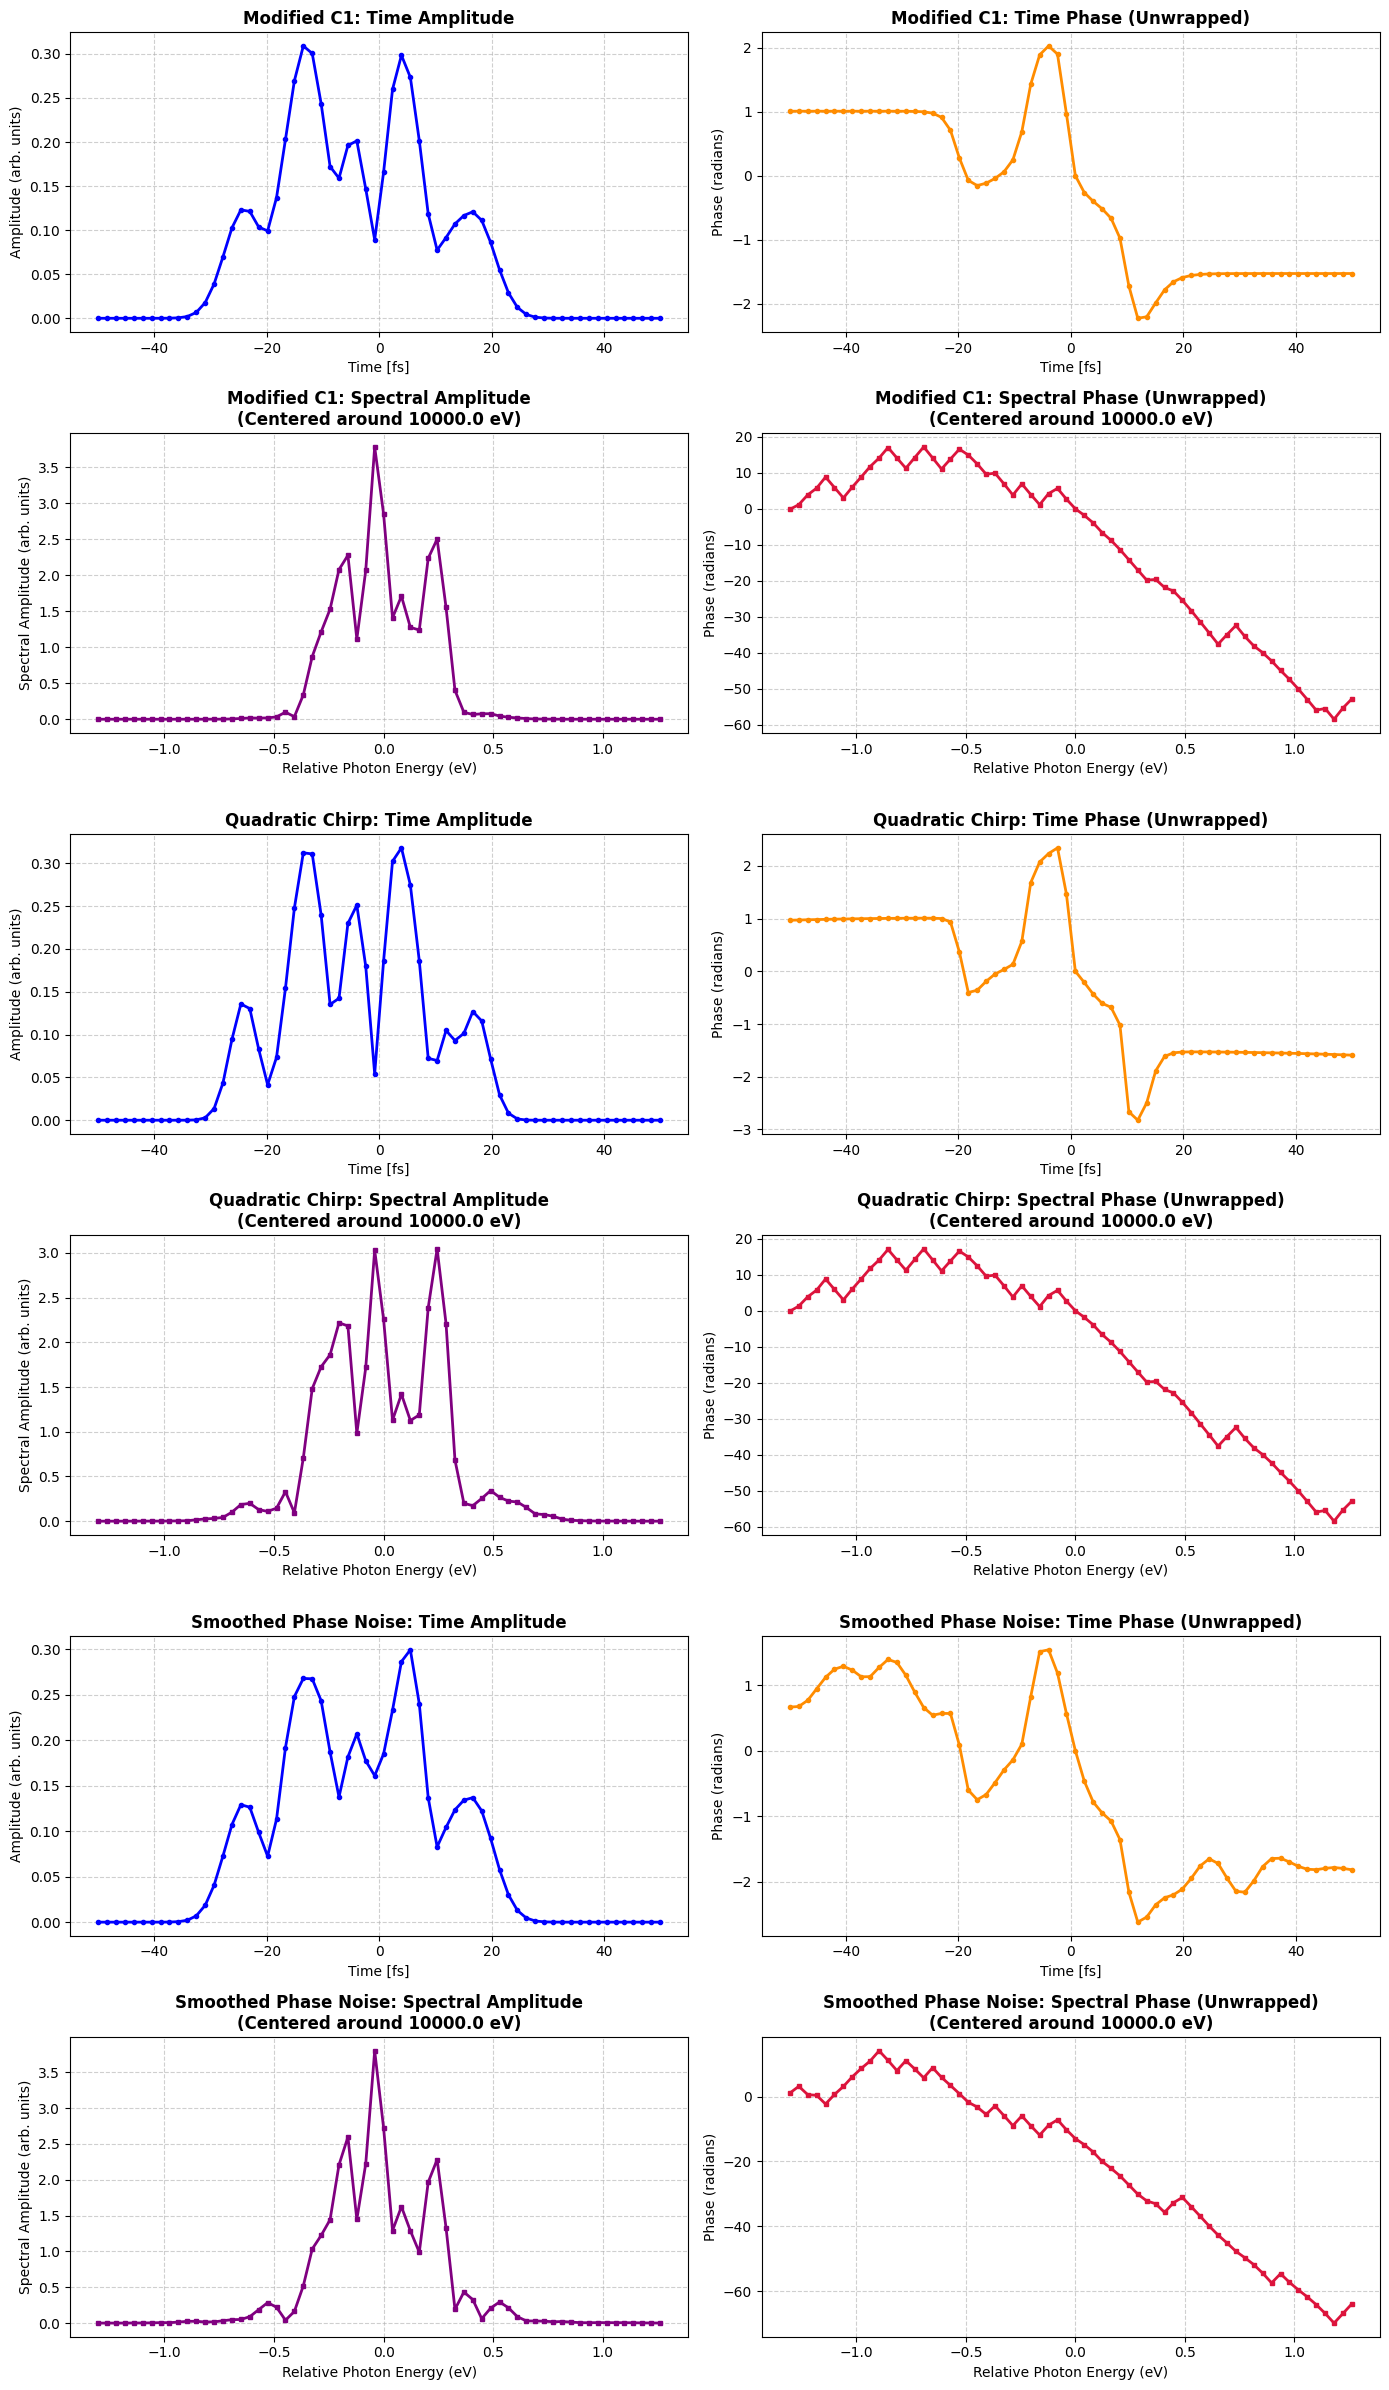

In [119]:
def plot_field_domain_panels(axs_block, f_t_field, f_v_field, model_label):
    """Plot 2x2 amplitude/phase panels for one field model."""
    amplitude_t = np.abs(f_t_field)
    phase_t = phase_t_unwrapped_at_zero(f_t_field)
    amplitude_v = np.abs(f_v_field)
    phase_v = np.unwrap(np.angle(f_v_field))

    axs_block[0, 0].plot(t, amplitude_t, color='blue', lw=2, marker='o', markersize=3)
    axs_block[0, 0].set_title(f'{model_label}: Time Amplitude', fontsize=12, fontweight='bold')
    axs_block[0, 0].set_xlabel('Time [fs]', fontsize=10)
    axs_block[0, 0].set_ylabel('Amplitude (arb. units)', fontsize=10)
    axs_block[0, 0].grid(True, linestyle='--', alpha=0.6)

    axs_block[0, 1].plot(t, phase_t, color='darkorange', lw=2, marker='o', markersize=3)
    axs_block[0, 1].set_title(f'{model_label}: Time Phase (Unwrapped)', fontsize=12, fontweight='bold')
    axs_block[0, 1].set_xlabel('Time [fs]', fontsize=10)
    axs_block[0, 1].set_ylabel('Phase (radians)', fontsize=10)
    axs_block[0, 1].grid(True, linestyle='--', alpha=0.6)

    axs_block[1, 0].plot(energy_ev_relative, amplitude_v, color='purple', lw=2, marker='s', markersize=3)
    axs_block[1, 0].set_title(
        f'{model_label}: Spectral Amplitude\n(Centered around {CENTRAL_ENERGY_EV} eV)',
        fontsize=12,
        fontweight='bold',
    )
    axs_block[1, 0].set_xlabel('Relative Photon Energy (eV)', fontsize=10)
    axs_block[1, 0].set_ylabel('Spectral Amplitude (arb. units)', fontsize=10)
    axs_block[1, 0].grid(True, linestyle='--', alpha=0.6)

    axs_block[1, 1].plot(energy_ev_relative, phase_v, color='crimson', lw=2, marker='s', markersize=3)
    axs_block[1, 1].set_title(
        f'{model_label}: Spectral Phase (Unwrapped)\n(Centered around {CENTRAL_ENERGY_EV} eV)',
        fontsize=12,
        fontweight='bold',
    )
    axs_block[1, 1].set_xlabel('Relative Photon Energy (eV)', fontsize=10)
    axs_block[1, 1].set_ylabel('Phase (radians)', fontsize=10)
    axs_block[1, 1].grid(True, linestyle='--', alpha=0.6)


field_models = {
    "modified_c1": (f_t_modified, f_v_modified, "Modified C1"),
    "quadratic_chirp": (f_t_quadratic, f_v_quadratic, "Quadratic Chirp"),
    "smoothed_phase_noise": (f_t_smoothed, f_v_smoothed, "Smoothed Phase Noise"),
}

if FIELD_TO_PLOT == "all":
    fig, axs = plt.subplots(6, 2, figsize=(14, 24))
    plot_field_domain_panels(axs[0:2, :], f_t_modified, f_v_modified, "Modified C1")
    plot_field_domain_panels(axs[2:4, :], f_t_quadratic, f_v_quadratic, "Quadratic Chirp")
    plot_field_domain_panels(axs[4:6, :], f_t_smoothed, f_v_smoothed, "Smoothed Phase Noise")
elif FIELD_TO_PLOT == "both":
    fig, axs = plt.subplots(4, 2, figsize=(14, 16))
    plot_field_domain_panels(axs[0:2, :], f_t_modified, f_v_modified, "Modified C1")
    plot_field_domain_panels(axs[2:4, :], f_t_quadratic, f_v_quadratic, "Quadratic Chirp")
else:
    f_t_sel, f_v_sel, label = field_models[FIELD_TO_PLOT]
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    plot_field_domain_panels(axs, f_t_sel, f_v_sel, label)

plt.tight_layout()
plt.show()

## Raw Pulses (Before Ambiguity Removal)

Same layout as the canonical SHG-FROG plots below, but using fields **before** `canonicalize_field`.

**Important:** The canonical plots use `phase_t_unwrapped_at_zero`, which **always subtracts** the phase at $t=0$ — so both raw and canonical look like $\phi(t=0)=0$ even when the raw field has a random global phase. Here we plot **`unwrap(angle(E))` without re-anchoring**, and show $\|E\|$ and $\arg E(t=0)$ in the titles so the difference is visible.

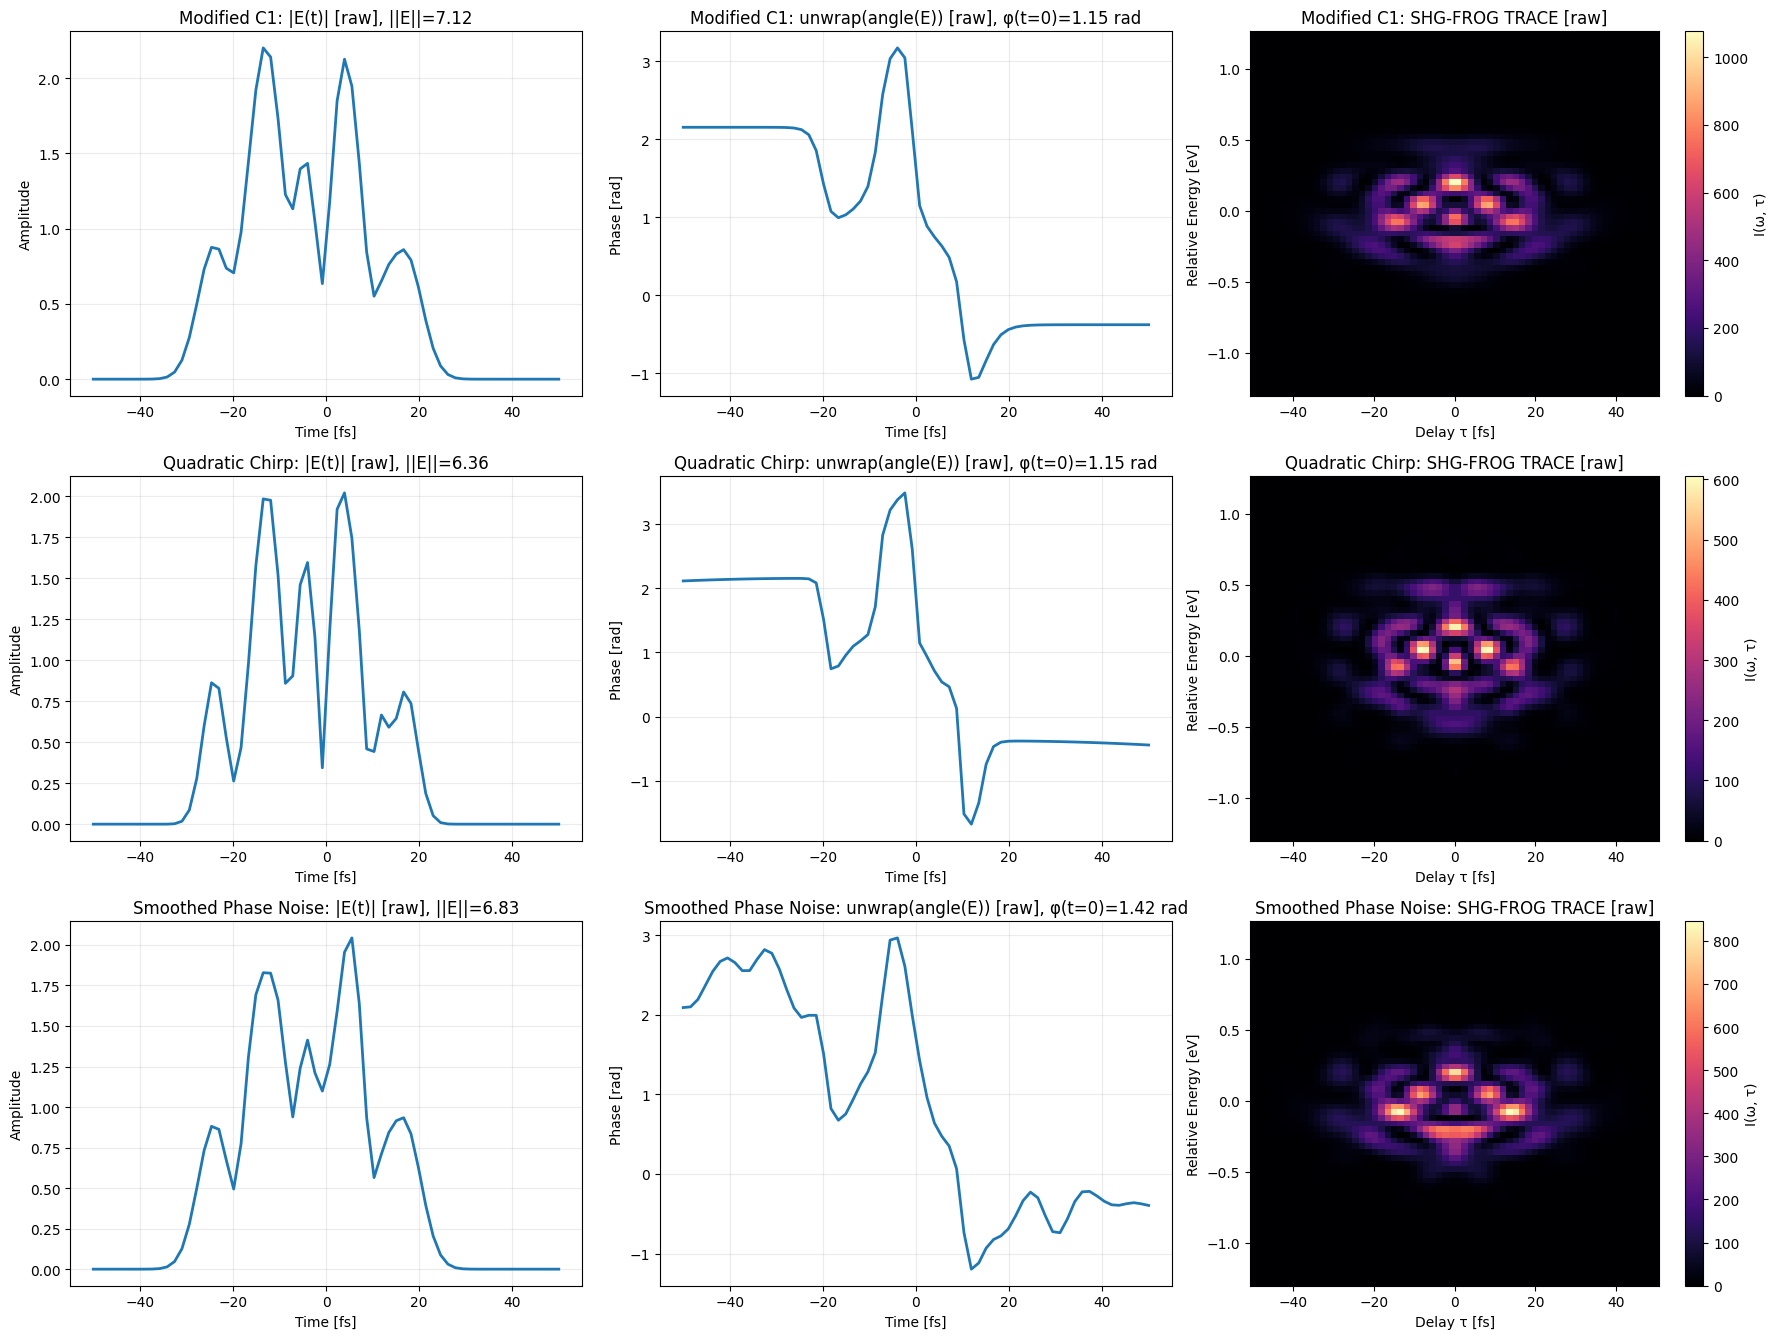

In [ ]:
import torch

from frognet import FROGNet
from pulse_metrics import prepare_frog_trace_for_plot


def compute_frog_trace_raw(f_t_field):
    frog = FROGNet(num_delay_steps=len(t))
    frog.eval()
    e_t_torch = torch.from_numpy(f_t_field.astype(np.complex64)).unsqueeze(0)
    with torch.no_grad():
        return frog(e_t_torch).squeeze(0).cpu().numpy()


def plot_frog_row_raw(fig, axes_row, f_t_field, model_label):
    trace = compute_frog_trace_raw(f_t_field)
    trace_plot, tau_axis, omega_plot = prepare_frog_trace_for_plot(
        trace,
        num_points=N_POINTS,
        dt=dt,
    )
    energy_plot = omega_plot * PLANCK_CONSTANT_FS_EV / (2.0 * np.pi)

    amp_t = np.abs(f_t_field)
    phase_t_plot = np.unwrap(np.angle(f_t_field))  # do NOT re-anchor at t=0
    phi0 = np.angle(f_t_field[zero_index])
    e_norm = np.linalg.norm(f_t_field)

    axes_row[0].plot(t, amp_t, lw=2)
    axes_row[0].set_title(f"{model_label}: |E(t)| [raw], ||E||={e_norm:.2f}")
    axes_row[0].set_xlabel("Time [fs]")
    axes_row[0].set_ylabel("Amplitude")
    axes_row[0].grid(alpha=0.25)

    axes_row[1].plot(t, phase_t_plot, lw=2)
    axes_row[1].set_title(f"{model_label}: unwrap(angle(E)) [raw], φ(t=0)={phi0:.2f} rad")
    axes_row[1].set_xlabel("Time [fs]")
    axes_row[1].set_ylabel("Phase [rad]")
    axes_row[1].grid(alpha=0.25)

    im = axes_row[2].imshow(
        trace_plot,
        origin="lower",
        aspect="auto",
        extent=[tau_axis[0], tau_axis[-1], energy_plot[0], energy_plot[-1]],
        cmap="magma",
    )
    axes_row[2].set_title(f"{model_label}: SHG-FROG TRACE [raw]")
    axes_row[2].set_xlabel("Delay τ [fs]")
    axes_row[2].set_ylabel("Relative Energy [eV]")
    fig.colorbar(im, ax=axes_row[2], label="I(ω, τ)")


frog_models_raw = {
    "modified_c1": (f_t_modified_raw, "Modified C1"),
    "quadratic_chirp": (f_t_quadratic_raw, "Quadratic Chirp"),
    "smoothed_phase_noise": (f_t_smoothed_raw, "Smoothed Phase Noise"),
}

if FIELD_TO_PLOT == "all":
    fig, axes = plt.subplots(3, 3, figsize=(18, 13.5))
    plot_frog_row_raw(fig, axes[0], f_t_modified_raw, "Modified C1")
    plot_frog_row_raw(fig, axes[1], f_t_quadratic_raw, "Quadratic Chirp")
    plot_frog_row_raw(fig, axes[2], f_t_smoothed_raw, "Smoothed Phase Noise")
elif FIELD_TO_PLOT == "both":
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    plot_frog_row_raw(fig, axes[0], f_t_modified_raw, "Modified C1")
    plot_frog_row_raw(fig, axes[1], f_t_quadratic_raw, "Quadratic Chirp")
else:
    f_t_sel_raw, label = frog_models_raw[FIELD_TO_PLOT]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    plot_frog_row_raw(fig, axes, f_t_sel_raw, label)

plt.tight_layout()
plt.show()

## SHG-FROG Spectrogram

Compute the SHG-FROG trace with `FROGNet` (same forward model as `pulses_generator_NB.ipynb`). The trace is `fftshift`ed along the frequency axis so that **0 eV** (DC) appears at the vertical center. Delay axis is in **femtoseconds**.

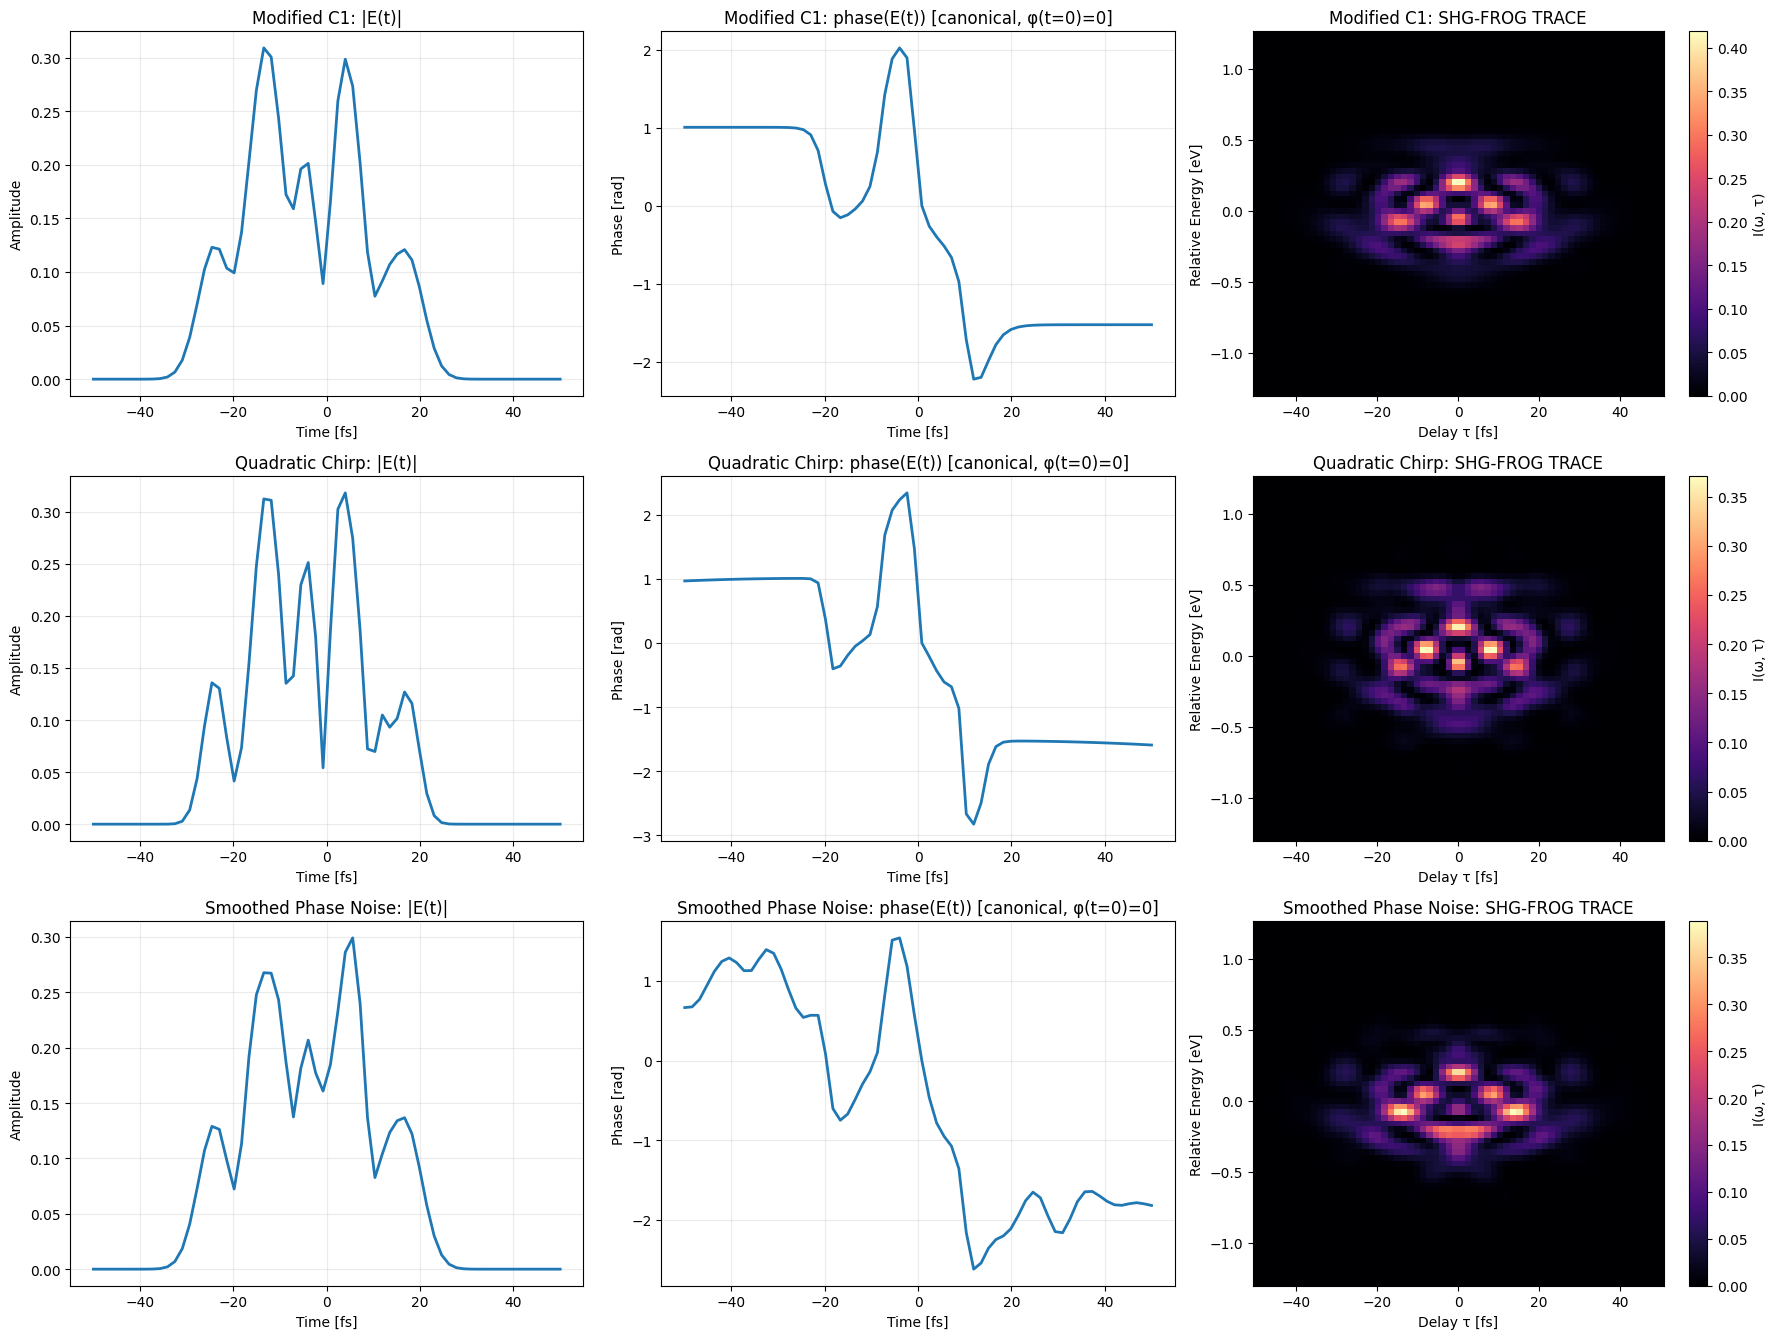

In [ ]:
import torch

from frognet import FROGNet
from pulse_metrics import prepare_frog_trace_for_plot


def compute_frog_trace(f_t_field):
    frog = FROGNet(num_delay_steps=len(t))
    frog.eval()
    e_t_torch = torch.from_numpy(f_t_field.astype(np.complex64)).unsqueeze(0)
    with torch.no_grad():
        return frog(e_t_torch).squeeze(0).cpu().numpy()


def plot_frog_row(fig, axes_row, f_t_field, model_label):
    trace = compute_frog_trace(f_t_field)
    trace_plot, tau_axis, omega_plot = prepare_frog_trace_for_plot(
        trace,
        num_points=N_POINTS,
        dt=dt,
    )
    energy_plot = omega_plot * PLANCK_CONSTANT_FS_EV / (2.0 * np.pi)

    amp_t = np.abs(f_t_field)
    phase_t_plot = phase_t_unwrapped_at_zero(f_t_field)

    axes_row[0].plot(t, amp_t, lw=2)
    axes_row[0].set_title(f"{model_label}: |E(t)|")
    axes_row[0].set_xlabel("Time [fs]")
    axes_row[0].set_ylabel("Amplitude")
    axes_row[0].grid(alpha=0.25)

    axes_row[1].plot(t, phase_t_plot, lw=2)
    axes_row[1].set_title(f"{model_label}: phase(E(t)) [canonical, φ(t=0)=0]")
    axes_row[1].set_xlabel("Time [fs]")
    axes_row[1].set_ylabel("Phase [rad]")
    axes_row[1].grid(alpha=0.25)

    im = axes_row[2].imshow(
        trace_plot,
        origin="lower",
        aspect="auto",
        extent=[tau_axis[0], tau_axis[-1], energy_plot[0], energy_plot[-1]],
        cmap="magma",
    )
    axes_row[2].set_title(f"{model_label}: SHG-FROG TRACE")
    axes_row[2].set_xlabel("Delay τ [fs]")
    axes_row[2].set_ylabel("Relative Energy [eV]")
    fig.colorbar(im, ax=axes_row[2], label="I(ω, τ)")


frog_models = {
    "modified_c1": (f_t_modified, "Modified C1"),
    "quadratic_chirp": (f_t_quadratic, "Quadratic Chirp"),
    "smoothed_phase_noise": (f_t_smoothed, "Smoothed Phase Noise"),
}

if FIELD_TO_PLOT == "all":
    fig, axes = plt.subplots(3, 3, figsize=(18, 13.5))
    plot_frog_row(fig, axes[0], f_t_modified, "Modified C1")
    plot_frog_row(fig, axes[1], f_t_quadratic, "Quadratic Chirp")
    plot_frog_row(fig, axes[2], f_t_smoothed, "Smoothed Phase Noise")
elif FIELD_TO_PLOT == "both":
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    plot_frog_row(fig, axes[0], f_t_modified, "Modified C1")
    plot_frog_row(fig, axes[1], f_t_quadratic, "Quadratic Chirp")
else:
    f_t_sel, label = frog_models[FIELD_TO_PLOT]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    plot_frog_row(fig, axes, f_t_sel, label)

plt.tight_layout()
plt.show()